# XGBoost Hyperparameter Tuning

Two-phase tuning using anchored-expanding cross-validation:

1. **Phase 1 (Random search)**: Broad random search across ~50 configs on a random subset of folds to understand the hyperparameter landscape and narrow ranges
2. **Phase 2 (Bayesian search)**: Optuna Bayesian optimization over the narrowed search space evaluated on ALL folds

CV structure: train always anchored at earliest date, 12-month validation window,
12-month holdout window, 1-month embargo, ~15 folds.

In [10]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from scipy.stats import spearmanr
import optuna
from joblib import Parallel, delayed
import multiprocessing
import xgboost as xgb


from src.features.gkx_registry import GKX_94
from src.ensemble import anchored_expanding_cv, XGBRanker

In [11]:
# ── Load data (same pattern as 001) ──
run_tag = "run_5000_nonetf_1990"
gkx_path = f"../data/processed/{run_tag}/gkx_monthly.parquet"
daily_path = f"../data/processed/{run_tag}/final_dataset.parquet"

gkx = pd.read_parquet(gkx_path)
daily = pd.read_parquet(daily_path)

# Fix _x/_y column suffixes
daily.drop(columns=[c for c in daily.columns if c.endswith("_x")], inplace=True)
daily.columns = [c.replace("_y", "") for c in daily.columns]

daily["date"] = pd.to_datetime(daily["date"])
daily["month_end"] = daily["date"] + pd.offsets.MonthEnd(0)

# Month-end close per ticker
px_m = (
    daily.sort_values(["ticker", "date"])
    .groupby(["ticker", "month_end"], as_index=False)
    .tail(1)[["ticker", "month_end", "close"]]
)
px_m = px_m.sort_values(["ticker", "month_end"])
px_m["ret_eom_t+1"] = px_m.groupby("ticker")["close"].shift(-1) / px_m["close"] - 1

# SPY benchmark return
spy = px_m.loc[px_m["ticker"] == "SPY", ["month_end", "ret_eom_t+1"]].rename(
    columns={"ret_eom_t+1": "spy_ret_eom_t+1"}
)

# Macro features
macro_cols = [
    'DFF', 'DGS10', 'DGS2', 'T10Y2Y', 'CPIAUCSL',
    'CPILFESL', 'PCEPI', 'GDP', 'GDPC1', 'INDPRO',
    'UNRATE', 'PAYEMS', 'ICSA', 'UMCSENT', 'RSXFS',
    'VIXCLS', 'DCOILWTICO', 'M2SL', 'TOTALSL'
]
macro_m = (
    daily.sort_values("date")
    .groupby("month_end", as_index=False)
    .tail(1)[["month_end"] + macro_cols]
    .drop_duplicates("month_end")
)

# Build modeling table
df = gkx.merge(px_m[["ticker", "month_end", "ret_eom_t+1"]], on=["ticker", "month_end"], how="left")
df = df.merge(spy, on="month_end", how="left")
df = df.merge(macro_m, on="month_end", how="left")
df["target_excess_t+1"] = df["ret_eom_t+1"] - df["spy_ret_eom_t+1"]

# Winsorize
lo = df.groupby("month_end")["target_excess_t+1"].transform(lambda x: x.quantile(0.01))
hi = df.groupby("month_end")["target_excess_t+1"].transform(lambda x: x.quantile(0.99))
df["target_excess_t+1"] = df["target_excess_t+1"].clip(lower=lo, upper=hi)

# Decile bins
df["target_excess_t+1_bins"] = (
    df.groupby("month_end")["target_excess_t+1"]
    .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates="drop"))
)

# Feature columns
all_gkx_cols = (
    [c for c in GKX_94]
    + [c + "_csnorm" for c in GKX_94]
    + [c + "_csrank" for c in GKX_94]
)
feature_cols = all_gkx_cols + macro_cols

# Filter to rows with valid target
model_df = df[["ticker", "month_end", "target_excess_t+1", "target_excess_t+1_bins"] + feature_cols].copy()
model_df = model_df[model_df["target_excess_t+1"].notna()].reset_index(drop=True)
model_df = model_df.replace([np.inf, -np.inf], np.nan)

print(f"Shape: {model_df.shape}")
print(f"Date range: {model_df['month_end'].min()} to {model_df['month_end'].max()}")
print(f"Unique months: {model_df['month_end'].nunique()}")
print(f"Features: {len(feature_cols)}")

Shape: (969002, 305)
Date range: 1993-01-31 00:00:00 to 2026-01-31 00:00:00
Unique months: 397
Features: 301


# Generate CV folds (~10 folds with step_months=24)
```python
cv_kwargs = dict(
    min_train_months=60,
    val_months=12,
    holdout_months=12,
    step_months=24,
    embargo_months=1,
)

folds = list(anchored_expanding_cv(model_df, date_col="month_end", **cv_kwargs))
print(f"Total folds: {len(folds)}\n")
```

# Summary table
```python
fold_summary = []
for f in folds:
    fold_summary.append({
        "fold": f["fold"],
        "train_end": f["train_end"].strftime("%Y-%m"),
        "val": f"{f['val_start'].strftime('%Y-%m')} \u2192 {f['val_end'].strftime('%Y-%m')}",
        "holdout": f"{f['holdout_start'].strftime('%Y-%m')} \u2192 {f['holdout_end'].strftime('%Y-%m')}",
        "n_train": f["train_mask"].sum(),
        "n_val": f["val_mask"].sum(),
        "n_holdout": f["holdout_mask"].sum(),
    })
fold_df = pd.DataFrame(fold_summary)
print(fold_df.to_string(index=False))
```

In [12]:
# Generate CV folds (~15 folds with step_months=16)
cv_kwargs = dict(
    min_train_months=108,
    val_months=12,
    holdout_months=12,
    step_months=24,
    embargo_months=1,
)

folds = list(anchored_expanding_cv(model_df, date_col="month_end", **cv_kwargs))
print(f"Total folds: {len(folds)}\n")

# Summary table
fold_summary = []
for f in folds:
    fold_summary.append({
        "fold": f["fold"],
        "train_end": f["train_end"].strftime("%Y-%m"),
        "val": f"{f['val_start'].strftime('%Y-%m')} \u2192 {f['val_end'].strftime('%Y-%m')}",
        "holdout": f"{f['holdout_start'].strftime('%Y-%m')} \u2192 {f['holdout_end'].strftime('%Y-%m')}",
        "n_train": f["train_mask"].sum(),
        "n_val": f["val_mask"].sum(),
        "n_holdout": f["holdout_mask"].sum(),
    })
fold_df = pd.DataFrame(fold_summary)
print(fold_df.to_string(index=False))

Total folds: 12

 fold train_end               val           holdout  n_train  n_val  n_holdout
    0   2001-12 2002-02 → 2003-01 2003-02 → 2004-01   137126  19735      20607
    1   2003-12 2004-02 → 2005-01 2005-02 → 2006-01   177315  21748      22803
    2   2005-12 2006-02 → 2007-01 2007-02 → 2008-01   221683  23907      25210
    3   2007-12 2008-02 → 2009-01 2009-02 → 2010-01   270602  26021      26458
    4   2009-12 2010-02 → 2011-01 2011-02 → 2012-01   322990  27535      28524
    5   2011-12 2012-02 → 2013-01 2013-02 → 2014-01   378886  29531      30898
    6   2013-12 2014-02 → 2015-01 2015-02 → 2016-01   439081  32618      34203
    7   2015-12 2016-02 → 2017-01 2017-02 → 2018-01   505641  35295      36795
    8   2017-12 2018-02 → 2019-01 2019-02 → 2020-01   577484  38918      40916
    9   2019-12 2020-02 → 2021-01 2021-02 → 2022-01   656968  43259      48347
   10   2021-12 2022-02 → 2023-01 2023-02 → 2024-01   747857  51408      52836
   11   2023-12 2024-02 → 2025-01 2

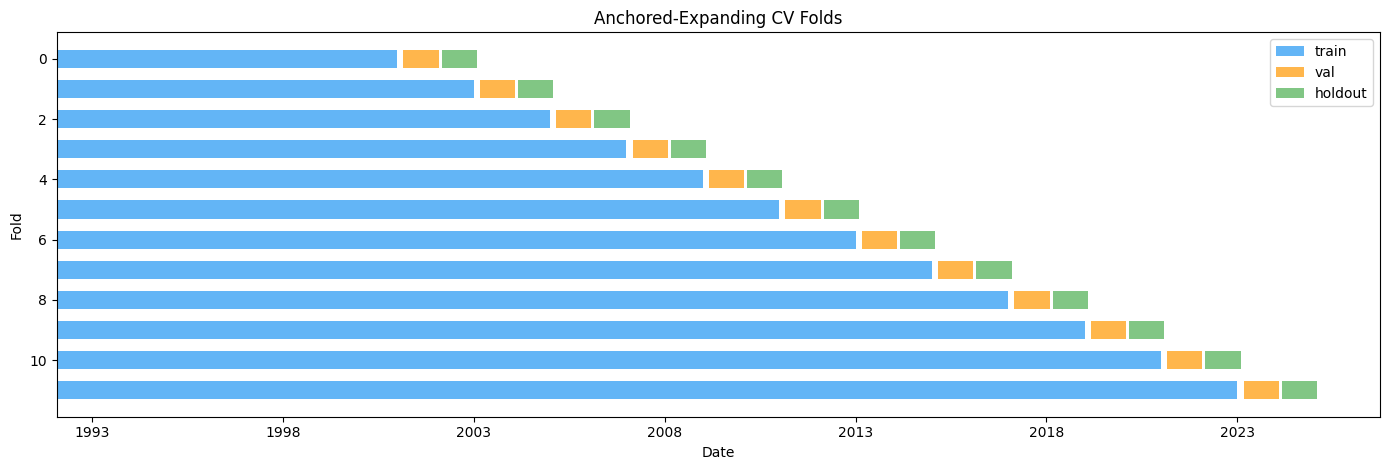

In [13]:
# Gantt chart of CV folds
fig, ax = plt.subplots(figsize=(14, max(4, len(folds) * 0.4)))

colors = {"train": "#2196F3", "val": "#FF9800", "holdout": "#4CAF50"}
dates_sorted = np.sort(model_df["month_end"].unique())
date_min, date_max = dates_sorted[0], dates_sorted[-1]

for f in folds:
    y = f["fold"]
    ax.barh(y, (f["train_end"] - date_min).days, left=0,
            height=0.6, color=colors["train"], alpha=0.7)
    ax.barh(y, (f["val_end"] - f["val_start"]).days,
            left=(f["val_start"] - date_min).days,
            height=0.6, color=colors["val"], alpha=0.7)
    ax.barh(y, (f["holdout_end"] - f["holdout_start"]).days,
            left=(f["holdout_start"] - date_min).days,
            height=0.6, color=colors["holdout"], alpha=0.7)

year_ticks = pd.date_range(date_min, date_max, freq="5YE")
ax.set_xticks([(t - date_min).days for t in year_ticks])
ax.set_xticklabels([t.strftime("%Y") for t in year_ticks])

ax.set_ylabel("Fold")
ax.set_xlabel("Date")
ax.set_title("Anchored-Expanding CV Folds")
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.7, label=l) for l, c in colors.items()]
ax.legend(handles=legend_elements, loc="upper right")
plt.tight_layout()
plt.show()

## Shared Helpers

In [30]:
from scipy.stats import spearmanr


def cross_sectional_ic(df, date_col, return_col, pred_col):
    """Average within-month Spearman IC (the correct cross-sectional measure)."""
    ic_list = []
    for _, group in df.groupby(date_col):
        y = group[return_col].values
        p = group[pred_col].values
        mask = np.isfinite(y) & np.isfinite(p)
        if mask.sum() < 10:
            continue
        corr, _ = spearmanr(y[mask], p[mask])
        if np.isfinite(corr):
            ic_list.append(corr)
    return np.mean(ic_list) if ic_list else 0.0


def compute_monthly_spreads(df, date_col, return_col, pred_col):
    """Top 10% minus bottom 10% mean return each month."""
    spreads = []
    for _, group in df.groupby(date_col):
        group = group.sort_values(pred_col)
        n = len(group)
        d = int(n * 0.1)
        if d < 1:
            continue
        bottom = group.iloc[:d][return_col].mean()
        top = group.iloc[-d:][return_col].mean()
        spreads.append(top - bottom)
    return np.array(spreads)


def sharpe_ratio(returns, annualization=12):
    if len(returns) < 3:
        return 0.0
    mean = np.mean(returns)
    std = np.std(returns)
    if std == 0:
        return 0.0
    return (mean / std) * np.sqrt(annualization)


def tail_score_predict(model, dmat):
    """P(top decile) - P(bottom decile) from multi:softprob model."""
    probs = model.predict(dmat)
    return probs[:, -1] - probs[:, 0]


def expected_decile_predict(model, dmat):
    """Expected decile: probs @ [0,1,...,9]. Smooth ranking score for full cross-section."""
    probs = model.predict(dmat)
    return probs @ np.arange(probs.shape[1], dtype=np.float32)


def evaluate_params_on_folds(params, fold_list):
    """
    Train XGBoost on each fold, predict with tail score.
    Returns dict with per-fold CS-IC values and per-fold spread arrays.
    """
    fold_ics = []
    fold_spreads = []

    for fold_info in fold_list:
        train_mask = fold_info["train_mask"]
        val_mask = fold_info["val_mask"]

        X_tr = model_df.loc[train_mask, feature_cols].values
        y_tr = model_df.loc[train_mask, "target_excess_t+1_bins"].values
        X_va = model_df.loc[val_mask, feature_cols].values
        y_va = model_df.loc[val_mask, "target_excess_t+1_bins"].values
        y_va_ret = model_df.loc[val_mask, "target_excess_t+1"].values

        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dval = xgb.DMatrix(X_va, label=y_va)

        full_params = {
            "objective": "multi:softprob",
            "num_class": 10,
            "eval_metric": "mlogloss",
            "tree_method": "hist",
            "nthread": 3,
            **params,
        }

        model = xgb.train(
            full_params,
            dtrain,
            num_boost_round=500,
            evals=[(dval, "valid")],
            early_stopping_rounds=30,
            verbose_eval=False,
        )

        # Expected decile for IC (smooth full-distribution ranking)
        ed_preds = expected_decile_predict(model, dval)
        
        # Tail score for spread diagnostic (extreme-focused)
        tail_preds = tail_score_predict(model, dval)

        val_df = model_df.loc[val_mask, ["month_end"]].copy()
        val_df["ret"] = y_va_ret
        val_df["ed_pred"] = ed_preds
        val_df["tail_pred"] = tail_preds

        # Cross-sectional IC using expected decile (tuning objective)
        cs_ic = cross_sectional_ic(val_df, "month_end", "ret", "ed_pred")
        fold_ics.append(cs_ic)

        # Spread using tail score (diagnostic)
        spreads = compute_monthly_spreads(
            val_df, date_col="month_end", return_col="ret", pred_col="tail_pred",
        )
        fold_spreads.append(spreads)

    return {"fold_ics": fold_ics, "fold_spreads": fold_spreads}


def score_fold_spreads(fold_spreads):
    """Sharpe per fold then average (not concatenated)."""
    fold_sharpes = [sharpe_ratio(s) for s in fold_spreads if len(s) >= 3]
    return np.mean(fold_sharpes) if fold_sharpes else 0.0

---
## Phase 1: Random Search (Landscape Exploration)

Broad grid, random sample of configs, evaluated on a random subset of folds.
Goal: understand which hyperparameter ranges matter and narrow the space.

In [15]:
# Broad search space
grid_values = dict(
    max_depth=[2, 4, 6],
    learning_rate=[0.01, 0.05, 0.1],
    subsample=[0.6, 0.75, 0.9],
    colsample_bytree=[0.4, 0.65, 0.9],
    min_child_weight=[1, 10, 20],
    alpha=[0.1, 1, 5],
)

param_grid = [
    dict(zip(grid_values.keys(), vals))
    for vals in product(*grid_values.values())
]
print(f"Full grid size: {len(param_grid)}")

# Random sample of configs
N_RANDOM = 1
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(param_grid), size=N_RANDOM, replace=False)
sampled_configs = [param_grid[i] for i in sample_idx]

# Random subset of folds for fast screening
N_FOLDS_P1 = 1
fold_idx = rng.choice(len(folds), size=N_FOLDS_P1, replace=False)
p1_folds = [folds[i] for i in sorted(fold_idx)]
print(f"Phase 1: {N_RANDOM} configs x {N_FOLDS_P1} folds (folds {sorted(fold_idx)})")

Full grid size: 729
Phase 1: 1 configs x 1 folds (folds [np.int32(4)])


### Run Phase 1 using parallel trials

In [16]:
N_CORES = multiprocessing.cpu_count()

import os

# Limit XGBoost to 4 threads
os.environ["OMP_NUM_THREADS"] = "3"

N_PARALLEL = 4  # 4 trials in parallel

def evaluate_single_config(params, idx):
    results = evaluate_params_on_folds(params, p1_folds)
    mean_ic = np.mean(results["fold_ics"]) if results["fold_ics"] else 0.0
    spread_sharpe = score_fold_spreads(results["fold_spreads"])

    all_spreads = np.concatenate(results["fold_spreads"]) if results["fold_spreads"] else np.array([])
    result = {
        **params,
        "mean_cs_ic": mean_ic,
        "spread_sharpe": spread_sharpe,
        "mean_spread": np.mean(all_spreads) if len(all_spreads) > 0 else 0.0,
    }

    print(f"[{idx+1}/{N_RANDOM}] CS-IC={mean_ic:.4f}  spread_sharpe={spread_sharpe:.3f}")
    return result


p1_results = Parallel(n_jobs=N_PARALLEL, backend="loky")(
    delayed(evaluate_single_config)(params, i)
    for i, params in enumerate(sampled_configs)
)

p1_df = (
    pd.DataFrame(p1_results)
      .sort_values("mean_cs_ic", ascending=False)
)

print("\nTop 10 configs (sorted by CS-IC):")
print(p1_df.head(10).to_string(index=False))


Top 10 configs (sorted by CS-IC):
 max_depth  learning_rate  subsample  colsample_bytree  min_child_weight  alpha  mean_cs_ic  spread_sharpe  mean_spread
         4            0.1        0.9              0.65                 1    0.1    0.011376       0.953521     0.007683


### Plot results from 1st phase

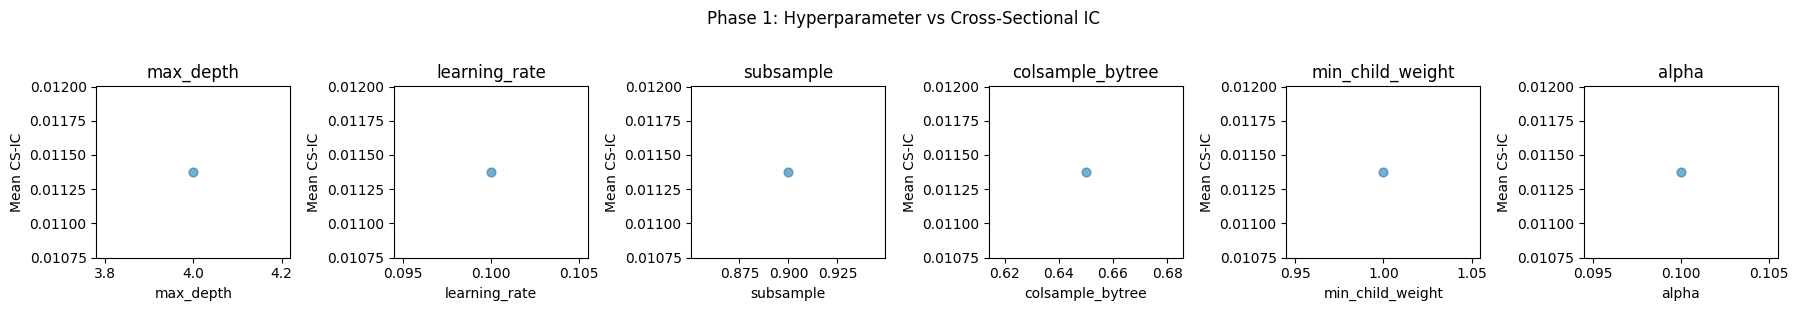

In [17]:
# Scatter plots: CS-IC vs each hyperparameter
hp_names = list(grid_values.keys())
fig, axes = plt.subplots(1, len(hp_names), figsize=(3 * len(hp_names), 3))

for ax, hp in zip(axes, hp_names):
    ax.scatter(p1_df[hp], p1_df["mean_cs_ic"], alpha=0.6, s=40)
    ax.set_xlabel(hp)
    ax.set_ylabel("Mean CS-IC")
    ax.set_title(hp)

fig.suptitle("Phase 1: Hyperparameter vs Cross-Sectional IC", y=1.02)
plt.tight_layout()
plt.show()

C:\Users\amsac\AppData\Local\Temp\ipykernel_25272\1719516628.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)
C:\Users\amsac\AppData\Local\Temp\ipykernel_25272\1719516628.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)
C:\Users\amsac\AppData\Local\Temp\ipykernel_25272\1719516628.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)
C:\Users\amsac\AppData\Local\Temp\ipykernel_25272

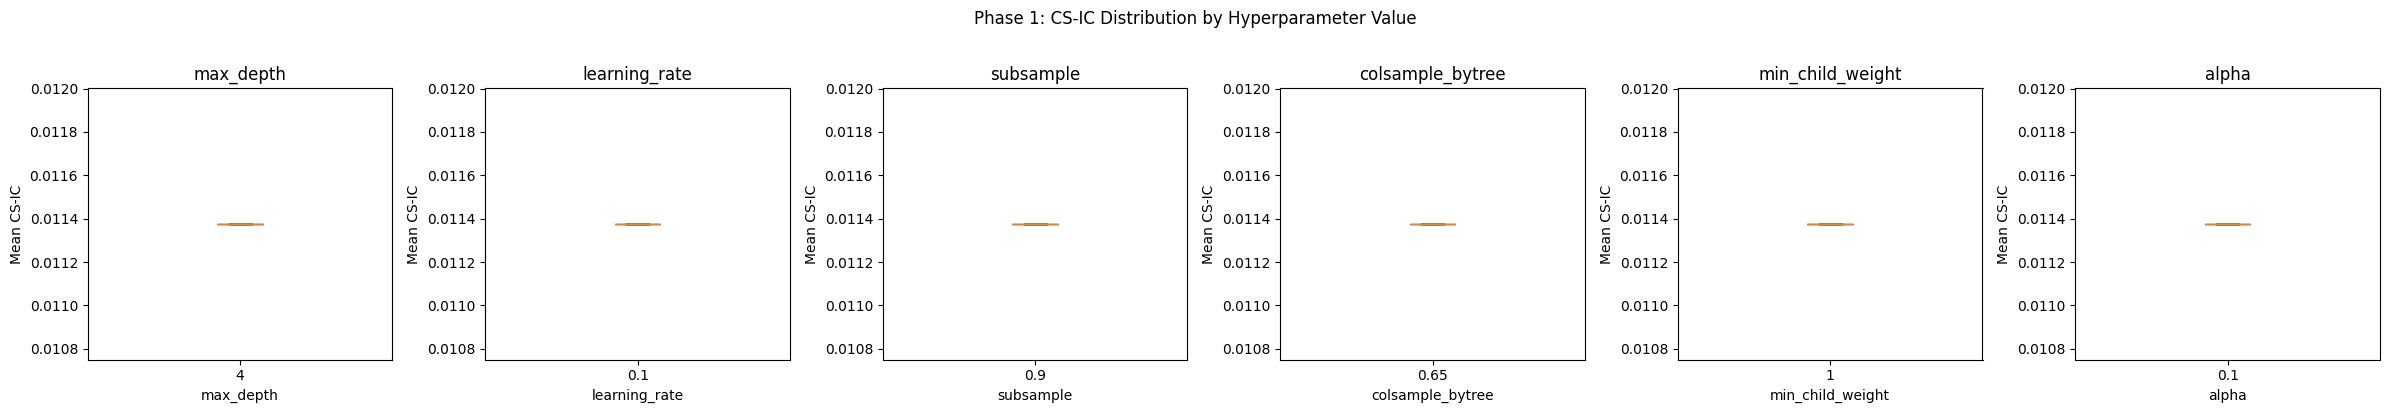

In [18]:
# Box plots: CS-IC distribution by hyperparameter value
fig, axes = plt.subplots(1, len(hp_names), figsize=(4 * len(hp_names), 4))

for ax, hp in zip(axes, hp_names):
    unique_vals = sorted(p1_df[hp].unique())
    data = [p1_df.loc[p1_df[hp] == v, "mean_cs_ic"].values for v in unique_vals]
    bp = ax.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#90CAF9")
    ax.set_xlabel(hp)
    ax.set_ylabel("Mean CS-IC")
    ax.set_title(hp)

fig.suptitle("Phase 1: CS-IC Distribution by Hyperparameter Value", y=1.02)
plt.tight_layout()
plt.show()

### Narrow the search space

Based on the Phase 1 scatter/box plots above, update the ranges below
to focus on the promising region before running Bayesian optimization.

In [19]:
# ── UPDATE THESE RANGES based on Phase 1 plots ──
# Defaults below are reasonable starting points; refine after inspecting plots.
NARROWED_SPACE = {
    "max_depth": (2, 4),              # (low, high) integer
    "learning_rate": (0.03, 0.08),     # (low, high) log-uniform
    "subsample": (0.80, 0.95),          # (low, high) uniform
    "colsample_bytree": (0.25, 0.6),   # (low, high) uniform
    "min_child_weight": (1, 20),      # (low, high) integer

    # Add new params
    "lambda": (0.001, 3.0), 
    "alpha": (0.001, 3.0)
}

print("Narrowed search space for Phase 2:")
for k, v in NARROWED_SPACE.items():
    print(f"  {k}: {v}")

Narrowed search space for Phase 2:
  max_depth: (2, 4)
  learning_rate: (0.03, 0.08)
  subsample: (0.8, 0.95)
  colsample_bytree: (0.25, 0.6)
  min_child_weight: (1, 20)
  lambda: (0.001, 3.0)
  alpha: (0.001, 3.0)


---
## Phase 2: Bayesian Optimization (All Folds)

Optuna TPE sampler explores the narrowed space efficiently.
Each trial is evaluated on ALL folds for robust estimation.

In [22]:
N_TRIALS = 1

def objective(trial):
    params = {
        "max_depth": trial.suggest_int(
            "max_depth", *NARROWED_SPACE["max_depth"]),
        "learning_rate": trial.suggest_float(
            "learning_rate", *NARROWED_SPACE["learning_rate"], log=True),
        "subsample": trial.suggest_float(
            "subsample", *NARROWED_SPACE["subsample"]),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", *NARROWED_SPACE["colsample_bytree"]),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", *NARROWED_SPACE["min_child_weight"]),
        "alpha": trial.suggest_float(
            "alpha", *NARROWED_SPACE["alpha"]),
        "lambda": trial.suggest_float(
            "lambda", *NARROWED_SPACE["lambda"]),
        "nthread": 3,
    }

    results = evaluate_params_on_folds(params, folds)  # ALL folds
    mean_ic = np.mean(results["fold_ics"]) if results["fold_ics"] else 0.0
    spread_sharpe = score_fold_spreads(results["fold_spreads"])

    # Store diagnostics
    all_spreads = np.concatenate(results["fold_spreads"]) if results["fold_spreads"] else np.array([])
    trial.set_user_attr("spread_sharpe", float(spread_sharpe))
    trial.set_user_attr("mean_spread", float(np.mean(all_spreads)) if len(all_spreads) > 0 else 0.0)
    trial.set_user_attr("per_fold_ic", [float(ic) for ic in results["fold_ics"]])
    trial.set_user_attr("per_fold_spread_sharpe",
                        [float(sharpe_ratio(s)) for s in results["fold_spreads"]])

    return mean_ic  # Optimize on CS-IC


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name="xgb_tuning_phase2",
)

# Seed the study with the best Phase 1 config
best_p1 = p1_df.iloc[0]
study.enqueue_trial({
    "max_depth": int(best_p1["max_depth"]),
    "learning_rate": float(best_p1["learning_rate"]),
    "subsample": float(best_p1["subsample"]),
    "colsample_bytree": float(best_p1["colsample_bytree"]),
    "min_child_weight": int(best_p1["min_child_weight"]),
    "alpha": int(best_p1["alpha"]),
    "lambda": 1.0,
})

print(f"Running {N_TRIALS} Bayesian trials on all {len(folds)} folds ({N_PARALLEL} parallel)...")
print("Objective: Cross-Sectional IC (maximize)")
study.optimize(objective, n_trials=N_TRIALS, n_jobs=N_PARALLEL, show_progress_bar=True)

print(f"\nBest trial #{study.best_trial.number}:")
print(f"  Mean CS-IC:      {study.best_value:.4f}")
print(f"  Spread Sharpe:   {study.best_trial.user_attrs['spread_sharpe']:.3f}")
print(f"  Mean spread:     {study.best_trial.user_attrs['mean_spread']:.4f}")
print(f"  Params:          {study.best_params}")

Running 1 Bayesian trials on all 12 folds (4 parallel)...
Objective: Cross-Sectional IC (maximize)


  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\.venv\Lib\site-packages\optuna\trial\_trial.py:658: UserWarning: Fixed parameter 'learning_rate' with value 0.1 is out of range for distribution FloatDistribution(high=0.08, log=True, low=0.03, step=None).
  optuna_warn(
c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\.venv\Lib\site-packages\optuna\trial\_trial.py:658: UserWarning: Fixed parameter 'colsample_bytree' with value 0.65 is out of range for distribution FloatDistribution(high=0.6, log=False, low=0.25, step=None).
  optuna_warn(
c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\.venv\Lib\site-packages\optuna\trial\_trial.py:658: UserWarning: Fixed parameter 'alpha' with value 0 is out of range for distribution FloatDistribution(high=3.0, log=False, low=0.001, step=None).
  optuna_warn(
Best trial: 0. Best value: 0.153763: 100%|██████████| 1/1 [10:30<00:00, 630.92s/it]


Best trial #0:
  Mean CS-IC:      0.1538
  Spread Sharpe:   5.673
  Mean spread:     0.0987
  Params:          {'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.65, 'min_child_weight': 1, 'alpha': 0.0, 'lambda': 1.0}


### Phase 2 Analysis

In [23]:
# Trial history
trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df["state"] == "COMPLETE"].sort_values("value", ascending=False)

display_cols = ["number", "value"] + [c for c in trials_df.columns if c.startswith("params_")]
print("Top 10 trials (value = mean CS-IC):")
print(trials_df[display_cols].head(10).to_string(index=False))

Top 10 trials (value = mean CS-IC):
 number    value  params_alpha  params_colsample_bytree  params_lambda  params_learning_rate  params_max_depth  params_min_child_weight  params_subsample
      0 0.153763           0.0                     0.65            1.0                   0.1                 4                        1               0.9


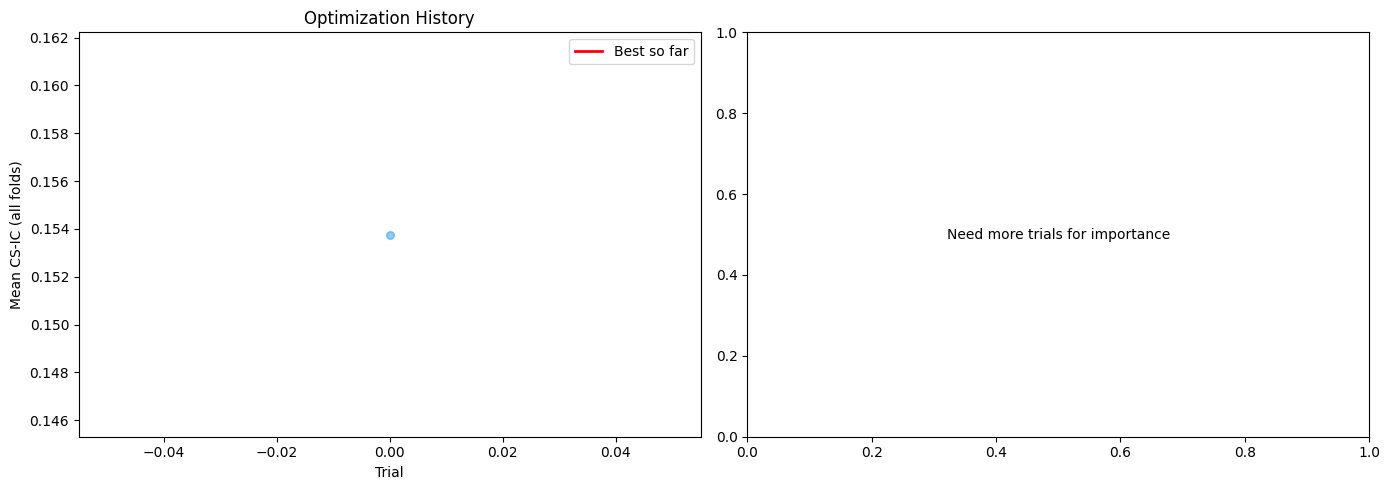

In [24]:
# Optimization history: CS-IC over trials
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_nums = [t.number for t in completed]
trial_vals = [t.value for t in completed]
ax.scatter(trial_nums, trial_vals, alpha=0.5, s=30, color="#2196F3")
running_best = np.maximum.accumulate(trial_vals)
ax.plot(trial_nums, running_best, color="red", linewidth=2, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Mean CS-IC (all folds)")
ax.set_title("Optimization History")
ax.legend()

# Hyperparameter importance
ax = axes[1]
try:
    importance = optuna.importance.get_param_importances(study)
    ax.barh(list(importance.keys()), list(importance.values()), color="#FF9800")
    ax.set_xlabel("Importance")
    ax.set_title("Hyperparameter Importance")
except Exception:
    ax.text(0.5, 0.5, "Need more trials for importance",
            ha="center", va="center", transform=ax.transAxes)

plt.tight_layout()
plt.show()

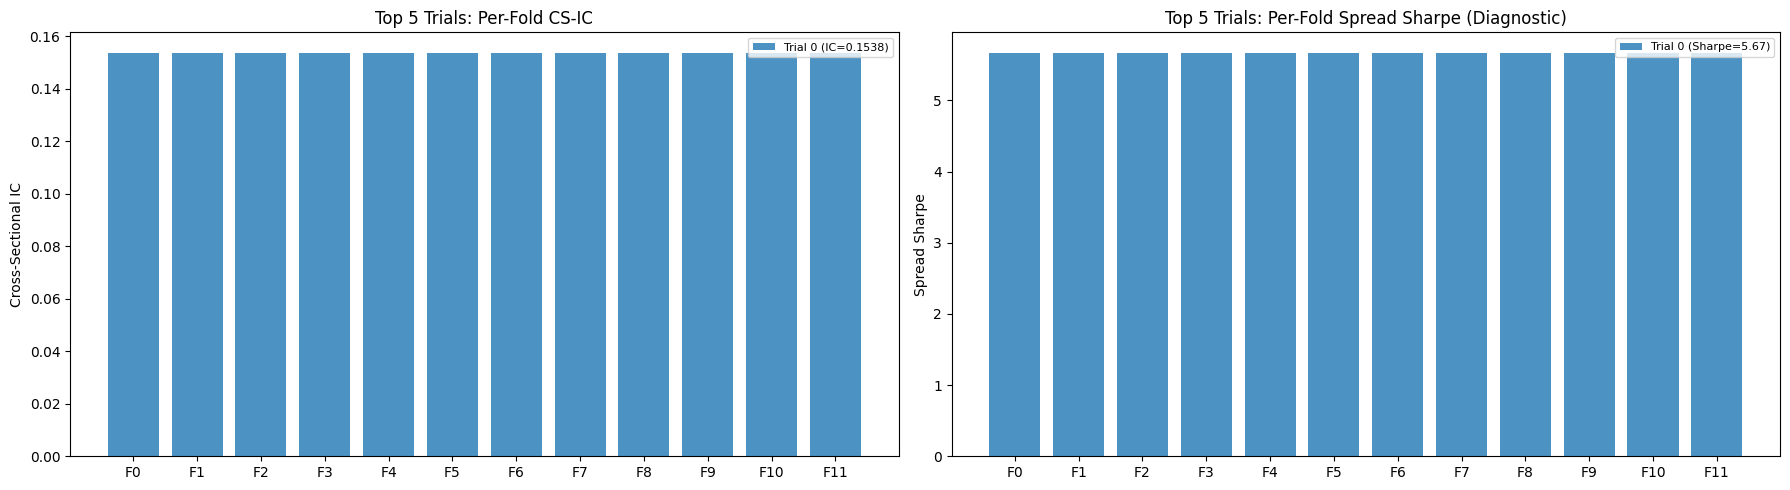

In [27]:
# Per-fold CS-IC for top 5 trials (with spread Sharpe as secondary diagnostic)
top_trials = sorted(
    [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
    key=lambda t: t.value, reverse=True,
)[:5]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Per-fold CS-IC
ax = axes[0]
n_top = len(top_trials)
x = np.arange(len(folds))
width = 0.8 / n_top

for i, trial in enumerate(top_trials):
    fold_ics = trial.user_attrs["per_fold_ic"]
    offset = (i - n_top / 2 + 0.5) * width
    ax.bar(x + offset, fold_ics, width,
           label=f"Trial {trial.number} (IC={trial.value:.4f})", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f"F{i}" for i in range(len(folds))])
ax.set_ylabel("Cross-Sectional IC")
ax.set_title("Top 5 Trials: Per-Fold CS-IC")
ax.legend(fontsize=8)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

# Per-fold spread Sharpe (diagnostic)
ax = axes[1]
for i, trial in enumerate(top_trials):
    fold_sharpes = trial.user_attrs["per_fold_spread_sharpe"]
    offset = (i - n_top / 2 + 0.5) * width
    ax.bar(x + offset, fold_sharpes, width,
           label=f"Trial {trial.number} (Sharpe={trial.user_attrs['spread_sharpe']:.2f})", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f"F{i}" for i in range(len(folds))])
ax.set_ylabel("Spread Sharpe")
ax.set_title("Top 5 Trials: Per-Fold Spread Sharpe (Diagnostic)")
ax.legend(fontsize=8)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

## Holdout Evaluation with Best Params

In [33]:
# Refit best model per fold, evaluate on HOLDOUT set using tail score
best_params = study.best_params
print(f"Evaluating best params on all holdout sets: {best_params}\n")

holdout_metrics = []

for fold_info in folds:
    train_mask = fold_info["train_mask"]
    val_mask = fold_info["val_mask"]
    holdout_mask = fold_info["holdout_mask"]

    X_tr = model_df.loc[train_mask, feature_cols].values
    y_tr = model_df.loc[train_mask, "target_excess_t+1_bins"].values
    X_va = model_df.loc[val_mask, feature_cols].values
    y_va = model_df.loc[val_mask, "target_excess_t+1_bins"].values
    X_ho = model_df.loc[holdout_mask, feature_cols].values
    y_ho_ret = model_df.loc[holdout_mask, "target_excess_t+1"].values
    me_ho = model_df.loc[holdout_mask, "month_end"].values

    # Train with same params used during tuning
    full_params = {
        "objective": "multi:softprob",
        "num_class": 10,
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        **best_params,
    }

    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dval = xgb.DMatrix(X_va, label=y_va)
    dho = xgb.DMatrix(X_ho)

    model = xgb.train(
        full_params,
        dtrain,
        num_boost_round=500,
        evals=[(dval, "valid")],
        early_stopping_rounds=30,
        verbose_eval=False,
    )

    # Expected decile for IC, tail score for spreads
    ed_preds = expected_decile_predict(model, dho)
    tail_preds = tail_score_predict(model, dho)

    ho_df = pd.DataFrame({
        "ed_pred": ed_preds, "tail_pred": tail_preds,
        "ret": y_ho_ret, "month_end": me_ho,
    })

    # Cross-sectional IC using expected decile
    cs_ic = cross_sectional_ic(ho_df, "month_end", "ret", "ed_pred")

    # Monthly spreads using tail score
    spreads = compute_monthly_spreads(ho_df, "month_end", "ret", "tail_pred")

    spread_sharpe = sharpe_ratio(spreads) if len(spreads) >= 3 else 0.0
    mean_spread = np.mean(spreads) if len(spreads) > 0 else np.nan

    holdout_metrics.append({
        "fold": fold_info["fold"],
        "holdout_start": fold_info["holdout_start"].strftime("%Y-%m"),
        "holdout_end": fold_info["holdout_end"].strftime("%Y-%m"),
        "cs_ic": cs_ic,
        "mean_spread": mean_spread,
        "spread_sharpe": spread_sharpe,
        "n_holdout": holdout_mask.sum(),
    })
    print(f"  Fold {fold_info['fold']}: CS-IC={cs_ic:.4f}, "
          f"Spread={mean_spread:.4f}, Sharpe={spread_sharpe:.2f}")

holdout_df = pd.DataFrame(holdout_metrics)
print(f"\nMean holdout CS-IC:        {holdout_df['cs_ic'].mean():.4f} (std={holdout_df['cs_ic'].std():.4f})")
print(f"Mean holdout spread:       {holdout_df['mean_spread'].mean():.4f}")
print(f"Mean holdout spread Sharpe: {holdout_df['spread_sharpe'].mean():.2f}")

Evaluating best params on all holdout sets: {'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.65, 'min_child_weight': 1, 'alpha': 0.0, 'lambda': 1.0}

  Fold 11: CS-IC=0.1344, Spread=0.0995, Sharpe=4.43

Mean holdout CS-IC:        0.1344 (std=nan)
Mean holdout spread:       0.0995
Mean holdout spread Sharpe: 4.43


In [34]:
holdout_df

,fold,holdout_start,holdout_end,cs_ic,mean_spread,spread_sharpe,n_holdout
0,11,2025-02,2026-01,0.134409,0.099478,4.432149,57887


## Diagnostic Plots

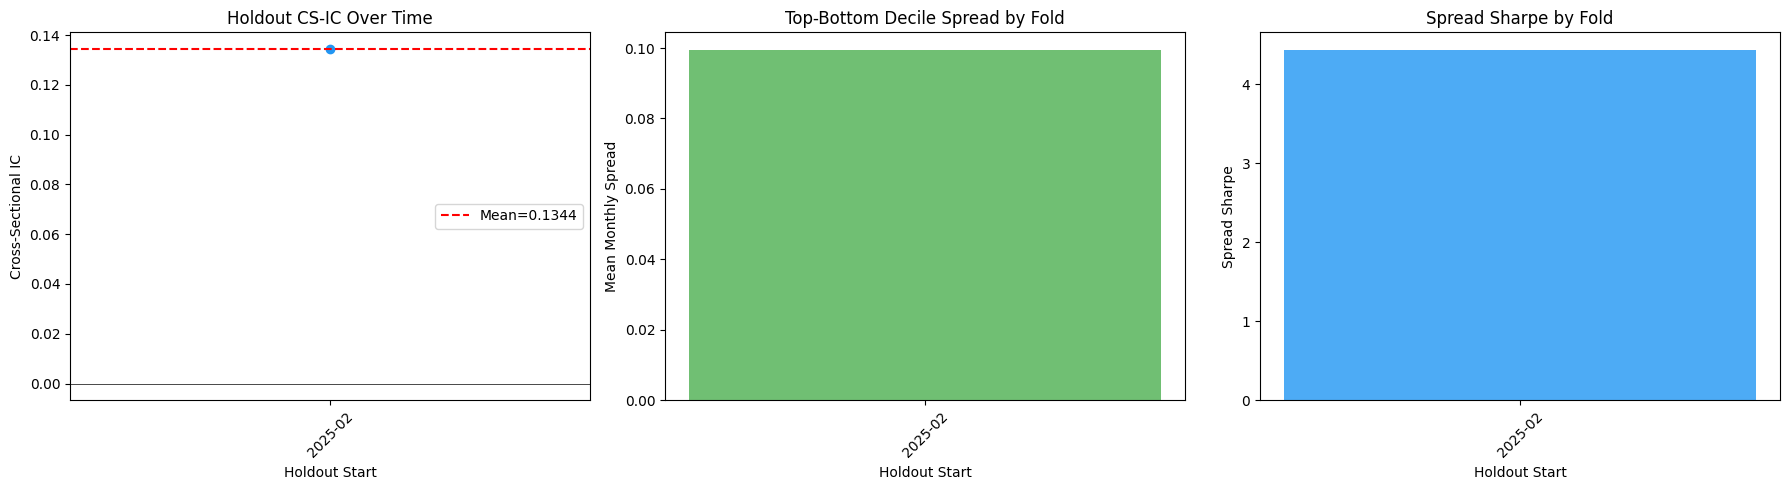

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cross-sectional IC over time
ax = axes[0]
ax.plot(holdout_df["holdout_start"], holdout_df["cs_ic"], "o-", color="#2196F3")
ax.axhline(holdout_df["cs_ic"].mean(), color="red", linestyle="--",
           label=f"Mean={holdout_df['cs_ic'].mean():.4f}")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Holdout Start")
ax.set_ylabel("Cross-Sectional IC")
ax.set_title("Holdout CS-IC Over Time")
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Mean spread per fold
ax = axes[1]
ax.bar(holdout_df["holdout_start"], holdout_df["mean_spread"],
       color=["#4CAF50" if s > 0 else "#f44336" for s in holdout_df["mean_spread"]],
       alpha=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Holdout Start")
ax.set_ylabel("Mean Monthly Spread")
ax.set_title("Top-Bottom Decile Spread by Fold")
ax.tick_params(axis='x', rotation=45)

# Spread Sharpe per fold
ax = axes[2]
ax.bar(holdout_df["holdout_start"], holdout_df["spread_sharpe"],
       color=["#2196F3" if s > 0 else "#f44336" for s in holdout_df["spread_sharpe"]],
       alpha=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Holdout Start")
ax.set_ylabel("Spread Sharpe")
ax.set_title("Spread Sharpe by Fold")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Feature importance from last fold's model (top 20)
if last_model is not None and last_model.model_ is not None:
    import xgboost as xgb
    fig, ax = plt.subplots(figsize=(8, 6))
    xgb.plot_importance(last_model.model_, max_num_features=20, ax=ax)
    ax.set_title("Top 20 Feature Importances (Last Fold)")
    plt.tight_layout()
    plt.show()

## Save Best Params

In [ ]:
# Save best params to JSON
out_path = f"../data/processed/{run_tag}/best_xgb_params.json"
with open(out_path, "w") as f:
    json.dump(best_params, f, indent=2)

print(f"Saved to {out_path}")
print(f"\nUsage:")
print(f"  from src.ensemble import XGBRanker")
print(f"  ranker = XGBRanker(params={best_params})")